# 1. Đọc dữ liệu

In [40]:
# Import các thư viện cần thiết
import os
import sys
import json 

base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'data', 'small_subset')

# Đọc train/dev/test small subset data
train_data = json.load(open(os.path.join(data_dir, 'small-train.json'), 'r', encoding='utf-8'))
dev_data = json.load(open(os.path.join(data_dir, 'small-dev.json'), 'r', encoding='utf-8'))
test_data = json.load(open(os.path.join(data_dir, 'small-test.json'), 'r', encoding='utf-8'))

In [41]:
def summarize_split(data, name):
    print(f"{name}: {len(data):,} mẫu")

summarize_split(train_data, "Train")
summarize_split(dev_data, "Dev")
summarize_split(test_data, "Test")

print("\nSample train:")
print(train_data[0])

Train: 20,000 mẫu
Dev: 2,000 mẫu
Test: 2,000 mẫu

Sample train:
{'english': 'It begins with a countdown .', 'vietnamese': 'Câu chuyện bắt đầu với buổi lễ đếm ngược .'}


> Khá ít nhưng đủ để train thử nghiệm

# 2. EDA

## 2.1 Phân tích độ dài câu - theo token

In [ ]:
# Tạm thời ta sẽ split theo whitespace và lowercase

def sentence_length_stats(data, lang="english"):
    '''Tính độ dài câu theo số token (word) trong ngôn ngữ cho trước'''
    lengths = [len(sample[lang].lower().split()) for sample in data]
    return lengths

In [43]:
en_lens = sentence_length_stats(train_data, "english")
vi_lens = sentence_length_stats(train_data, "vietnamese")

print("English:")
print(f"  Mean   : {sum(en_lens)/len(en_lens):.2f}")
print(f"  Max    : {max(en_lens)}")

print("Vietnamese:")
print(f"  Mean   : {sum(vi_lens)/len(vi_lens):.2f}")
print(f"  Max    : {max(vi_lens)}")

English:
  Mean   : 19.79
  Max    : 164
Vietnamese:
  Mean   : 23.76
  Max    : 179


> Có thể thấy câu tiếng Việt có xu hướng dài hơn câu tiếng anh, mean là ổn, vì đây là data cặp câu, nên không có vụ mất cân bằng. Điều này là hợp lý do tiếng việt thường có cấu trúc dài hơn.

## 2.2 Phân tích phân phối độ dài để chọn `max_len`

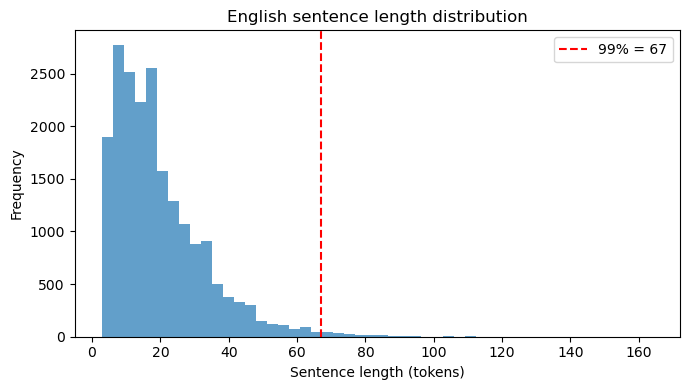

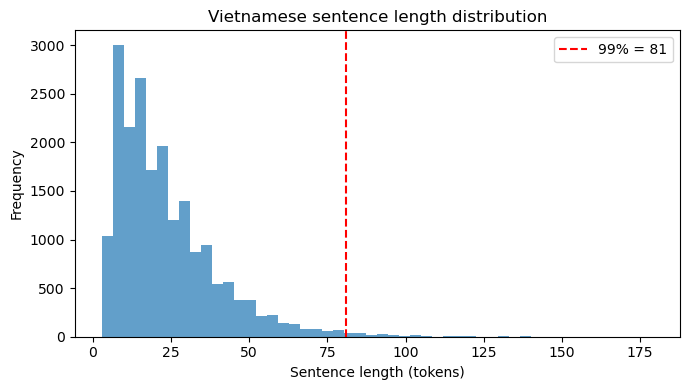

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def plot_length_distribution(lengths, title):
    p99 = np.percentile(lengths, 99)

    plt.figure(figsize=(7,4))
    plt.hist(lengths, bins=50, alpha=0.7)
    plt.axvline(p99, color="red", linestyle="--", label=f"99% = {int(p99)}")
    plt.title(title)
    plt.xlabel("Sentence length (tokens)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_length_distribution(en_lens, "English sentence length distribution")
plot_length_distribution(vi_lens, "Vietnamese sentence length distribution")

Phân phối độ dài câu lệch phải mạnh, có 1 số outliers cho câu dài bất thường.

Đối với 99% câu:

- English ≤ 67 tokens

- Vietnamese ≤ 81 tokens

Sau đây ta sẽ thử in ra độ dại của câu tiếng việt so với tiếng anh, để quyết định chọn `max_length` phù hợp

In [45]:
length_ratios = [
    len(s["vietnamese"].split()) / max(len(s["english"].split()), 1)
    for s in train_data
]

print(f"Mean ratio (VI / EN): {sum(length_ratios)/len(length_ratios):.2f}")

Mean ratio (VI / EN): 1.22


Câu tiếng việt trung bình dài hơn câu tiếng anh 1.22 lần, phù hợp đặc trưng ngôn ngữ.

=> Ta sẽ chọn `max_len` dựa trên 99% phân vị (99% câu có độ dài nhỏ hơn)

- max_src_len = 70 (99% câu tiếng Anh ≤ 67 tokens)
- max_tgt_len = 85 (99% câu tiếng Việt ≤ 81 tokens)

=> Ngoài ra tgt_len cũng cần chỗ cho eos và bos - maximum target sequence length INCLUDING special tokens

Thêm vào đó ta cũng thấy 85/70 ~ 1.21

## 2.3 Phân tích tập từ điển để chọn `min_freq`

In [46]:
from collections import Counter

def build_token_counter(data, lang="english"):
    counter = Counter()
    for sample in data:
        tokens = sample[lang].lower().split()
        counter.update(tokens)
    return counter

en_counter = build_token_counter(train_data, "english")
vi_counter = build_token_counter(train_data, "vietnamese")

In [47]:
def rare_token_stats(counter, thresholds=[1, 2, 5]):
    total_vocab = len(counter)
    print(f"Total vocab: {total_vocab}")
    for t in thresholds:
        rare = sum(1 for _, c in counter.items() if c <= t)
        print(f"Tokens with freq ≤ {t}: {rare} ({rare/total_vocab:.2%})")

print("English vocab stats:")
rare_token_stats(en_counter)

print("\nVietnamese vocab stats:")
rare_token_stats(vi_counter)

English vocab stats:
Total vocab: 17414
Tokens with freq ≤ 1: 7334 (42.12%)
Tokens with freq ≤ 2: 10016 (57.52%)
Tokens with freq ≤ 5: 13138 (75.45%)

Vietnamese vocab stats:
Total vocab: 7057
Tokens with freq ≤ 1: 2749 (38.95%)
Tokens with freq ≤ 2: 3612 (51.18%)
Tokens with freq ≤ 5: 4543 (64.38%)


>Tiếng anh có nhiều từ vựng hơn, mặc dù số từ trong câu ngắn hơn, có thể là do việc cắt ngắn dataset bị bias hoặc do việc tiếng anh có nhiều hậu tố được gán thành các token khác nhau (Ví dụ: run, ran, runing,...)

>Do phân phối từ vựng xuất hiện nhiều từ hiếm (xuất hiện <1 lần), đặc biệt ở tiếng Anh, ta sẽ áp dụng ngưỡng tần suất tối thiểu khi xây dựng tập từ điển. Cụ thể, min_freq = 2 được sử dụng cho cả hai ngôn ngữ nhằm giảm kích thước từ vựng và hạn chế nhiễu từ các từ hiếm.